In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
from scipy import stats
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

In [2]:
ROOT = '../data/processed/'
DATASET = ROOT+'2024_saliva_experiment/df_glucose_pilot_saliva_sweat_2025.csv'

df_experiment= pd.read_csv(DATASET)

In [3]:
df_experiment.tail(5)

,condition,type,glucose_mg_ml,glucose_mg_dl
8141,Saliva_After_Eating_25,Colorimetric Sensors,0.084732,8.473229
8142,Saliva_After_Eating_25,Colorimetric Sensors,0.158020,15.801954
8143,Saliva_After_Eating_25,Colorimetric Sensors,0.158020,15.801954
8144,Saliva_After_Eating_25,Colorimetric Sensors,0.170041,17.004089
8145,Saliva_After_Eating_25,Colorimetric Sensors,0.113611,11.361070


In [4]:
# Separate df per sensor type

df_blood = df_experiment[df_experiment['type'] == 'Blood'].reset_index()

df_elisa = df_experiment[df_experiment['type'] == 'ELISA'].reset_index()

df_color_sensors = df_experiment[df_experiment['type'] == 'Colorimetric Sensors'].reset_index()


In [23]:
df_blood

,index,condition,type,glucose_mg_ml,glucose_mg_dl
0,0,Saliva_Control,Blood,0.86,86.0
1,1,Saliva_After_Exercise,Blood,0.96,96.0
2,2,Saliva_After_Eating_10,Blood,0.87,87.0
3,3,Saliva_After_Eating_25,Blood,1.01,101.0
4,4,Sweat_After_Exercise,Blood,NaN,NaN


In [5]:
df_color_sensors['condition'].unique()

array(['Saliva_Control', 'Saliva_After_Exercise', 'Sweat_After_Exercise',
       'Saliva_After_Eating_10', 'Saliva_After_Eating_25'], dtype=object)

In [20]:
# Sample data for three groups
conditions = df_color_sensors['condition'].unique()

dict_conditions = {}
for c in conditions:
    dict_conditions[c] = df_color_sensors[df_color_sensors['condition']==c]['glucose_mg_ml'].to_numpy()

# Perform the Kruskal-Wallis H-test
statistic, p_value = stats.kruskal(
    dict_conditions['Saliva_Control'],
    dict_conditions['Saliva_After_Exercise'],
    #dict_conditions['Sweat_After_Exercise'],
    dict_conditions['Saliva_After_Eating_10'],
    dict_conditions['Saliva_After_Eating_25'],
)

print(f"H-statistic: {statistic:.3f}")
print(f"P-value: {p_value:.8e}")


# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: significant differences exist between groups.")
else:
    print("Fail to reject the null hypothesis: no significant differences.")

H-statistic: 5392.224
P-value: 0.00000000e+00
Reject the null hypothesis: significant differences exist between groups.


COMPARISON
Saliva_Control  vs.  Saliva_After_Exercise
U statistic: 688352.5
P-value: 2.648e-228
Reject null hypothesis: Significant difference between groups.


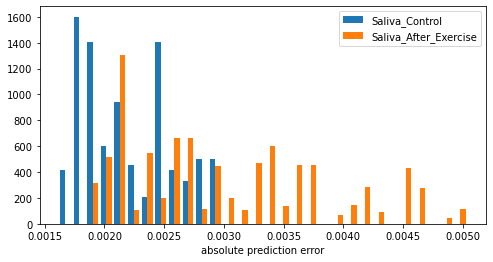

COMPARISON
Saliva_Control  vs.  Saliva_After_Eating_10
U statistic: 0.0
P-value: 0.000e+00
Reject null hypothesis: Significant difference between groups.


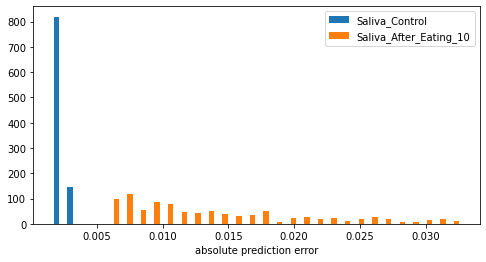

COMPARISON
Saliva_Control  vs.  Saliva_After_Eating_25
U statistic: 0.0
P-value: 0.000e+00
Reject null hypothesis: Significant difference between groups.


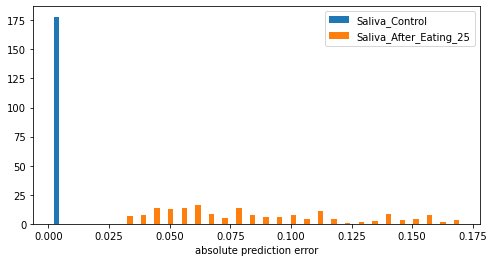

In [22]:
# Statistical Test

CONDITION_A = 'Saliva_Control'

CONDITIONS_B = ['Saliva_After_Exercise', 'Saliva_After_Eating_10', 'Saliva_After_Eating_25']

p_vals_all = []

for temp_condition in CONDITIONS_B:
    statistic, p_value = mannwhitneyu(
        dict_conditions[CONDITION_A], 
        dict_conditions[temp_condition], 
        alternative='less'
    )

    print('COMPARISON')
    print(CONDITION_A, ' vs. ',temp_condition)
    print("U statistic:", statistic)
    print(f"P-value: {p_value:.3e}")
    if p_value < 0.05:
        print("Reject null hypothesis: Significant difference between groups.")
    else:
        print("Fail to reject null hypothesis: No significant difference.")

    # Plot comparison
    plt.figure(figsize=(8, 4))
    plt.xlabel('absolute prediction error')
    plt.hist([dict_conditions[CONDITION_A], dict_conditions[temp_condition]], bins=30, label=[CONDITION_A,temp_condition], density=True)
    plt.legend(loc="upper right")
    plt.show()
    
    # Save p-values for correction
    p_vals_all.append(p_value)


COMPARISON
Saliva_After_Eating_10  vs.  Saliva_After_Eating_25
U statistic: 165.0
P-value: 0.000000000000000e+00
Reject null hypothesis: Significant difference between groups.


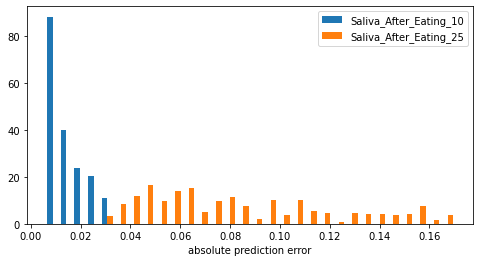

In [8]:
# Statistical Test

CONDITION_A = 'Saliva_After_Eating_10'

CONDITION_B = 'Saliva_After_Eating_25'


statistic, p_value = mannwhitneyu(
    dict_conditions[CONDITION_A], 
    dict_conditions[CONDITION_B], 
    alternative='less'
)

print('COMPARISON')
print(CONDITION_A, ' vs. ',CONDITION_B)
print("U statistic:", statistic)
print(f"P-value: {p_value:.15e}")
if p_value < 0.05:
    print("Reject null hypothesis: Significant difference between groups.")
else:
    print("Fail to reject null hypothesis: No significant difference.")

# Plot comparison
plt.figure(figsize=(8, 4))
plt.xlabel('absolute prediction error')
plt.hist([dict_conditions[CONDITION_A], dict_conditions[CONDITION_B]], bins=30, 
         label=[CONDITION_A,CONDITION_B], density=True)
plt.legend(loc="upper right")
plt.show()

# Save p-values for correction
p_vals_all.append(p_value)

In [9]:
from statsmodels.stats.multitest import multipletests
print('original p-vals:',p_vals_all)
rejected, p_adjusted, _, _ = multipletests(p_vals_all, alpha=0.05, method='fdr_bh')
print('adjusted p-vals:',p_adjusted)

original p-vals: [2.647791581299866e-228, 0.0, 0.0, 0.0]
adjusted p-vals: [2.64779158e-228 0.00000000e+000 0.00000000e+000 0.00000000e+000]


In [10]:
# Example
p_values = [0.001, 0.002, 0.003, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.1]
rejected, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
print(p_adjusted)

[0.01       0.01       0.01       0.025      0.04       0.05
 0.05714286 0.0625     0.06666667 0.1       ]


## Differential Changes

In [18]:
median_sweat_exercise = df_color_sensors[df_color_sensors['condition']=='Sweat_After_Exercise']['glucose_mg_ml'].median()
print(median_sweat_exercise)

0.0036885199455182


In [11]:
# Min Max Range
global_Deviation_color = (df_color_sensors['glucose_mg_ml'].max()-df_color_sensors['glucose_mg_ml'].min())

#global_Deviation = df_color_sensors['glucose_mg_ml'].std()

print(global_Deviation_color)

0.1684244831299133


In [12]:
# Percentile Change
median_Baseline = df_color_sensors[df_color_sensors['condition']=='Saliva_Control']['glucose_mg_ml'].median()
median_exercise = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Exercise']['glucose_mg_ml'].median()
median_post_10 = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_10']['glucose_mg_ml'].median()
median_post_25 = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_25']['glucose_mg_ml'].median()

print('Medians', median_Baseline, median_exercise, median_post_10, median_post_25)

# Baseline vs Exercise
change_in_iqr_exe = (median_exercise - median_Baseline)/global_Deviation_color
print('change_in_exe', change_in_iqr_exe*100)

# Baseline vs PostPrandial 10
change_in_iqr_10 = (median_post_10 - median_Baseline)/global_Deviation_color
print('change_in_10', change_in_iqr_10*100)

# Baseline vs PostPrandial 25
change_in_iqr_25 = (median_post_25 - median_Baseline)/global_Deviation_color
print('change_in_25', change_in_iqr_25*100)


Medians 0.0020892926565015 0.0028013640453932 0.0121400622297217 0.0759075747972915
change_in_exe 0.42278377564765784
change_in_10 5.967522884109192
change_in_25 43.82871229229225


# ELISA differences

In [13]:
df_elisa_no_nas = df_elisa.dropna().reset_index()

In [14]:
global_Deviation_elisa = (df_elisa_no_nas['glucose_mg_ml'].max()-df_elisa_no_nas['glucose_mg_ml'].min())
print(global_Deviation_elisa)

0.112306


In [15]:
# Percentile Change
median_Baseline = df_elisa_no_nas[df_elisa_no_nas['condition']=='Saliva_Control']['glucose_mg_ml'].median()
median_exercise = df_elisa_no_nas[df_elisa_no_nas['condition']=='Saliva_After_Exercise']['glucose_mg_ml'].median()
median_post_10 = df_elisa_no_nas[df_elisa_no_nas['condition']=='Saliva_After_Eating_10']['glucose_mg_ml'].median()
median_post_25 = df_elisa_no_nas[df_elisa_no_nas['condition']=='Saliva_After_Eating_25']['glucose_mg_ml'].median()

print('Medians', median_Baseline, median_exercise, median_post_10, median_post_25)

# Baseline vs Exercise
change_in_iqr_exe = (median_exercise - median_Baseline)/global_Deviation_elisa
print('change_in_exe', change_in_iqr_exe*100)

# Baseline vs PostPrandial 10
change_in_iqr_10 = (median_post_10 - median_Baseline)/global_Deviation_elisa
print('change_in_10', change_in_iqr_10*100)

# Baseline vs PostPrandial 25
change_in_iqr_25 = (median_post_25 - median_Baseline)/global_Deviation_elisa
print('change_in_25', change_in_iqr_25*100)


Medians 0.018277500000000002 0.020855 0.0664845 0.0731695
change_in_exe 2.295068829804282
change_in_10 42.92468790625612
change_in_25 48.877174861539004


In [16]:
# with std is the same as

In [17]:
def z_score_standardization(series):
    return (series - series.mean()) / series.std()

df_color_sensors['glucose_z_score'] = z_score_standardization(df_color_sensors['glucose_mg_ml'])